# Análisis Exploratorio de Datos (EDA)
# 1 INTRODUCCIÓN
En este notebook se realiza un análisis exploratorio del dataset **MIMIC-IV** utilizado en este trabajo.

El objetivo es comprender la estructura del dataset, analizar la distribución de las variables principales y detectar posibles problemas de calidad de los datos.

El análisis se centra en cinco tablas principales:

- `patients`
- `admissions`
- `diagnoses_icd`
- `procedures_icd`
- `prescriptions`



En esta sección inicial, cargaremos los datasets del MIMIC-IV utilizando la configuración definida en `src/config.py`. Esto incluye las tablas de pacientes, admisiones, diagnósticos y procedimientos. Posteriormente, se extraen lastablas en variables  para poder trabajar con ellas.

In [1]:
import sys
import os
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

sys.path.append(os.path.abspath(".."))
from src.config import FILES
from src.data.load import load_multiple_datasets


Ahora se cargan los datasets desde los archivos definidos en la configuración. Se utiliza la función `load_multiple_datasets` para importar los datos de pacientes, admisiones, diagnósticos y procedimientos del MIMIC-IV. Los datasets se almacenan en un diccionarior.

In [2]:
datasets = load_multiple_datasets(FILES)

Loading patients...
Loading admissions...
Loading diagnoses...
Loading procedures...
Loading prescriptions...


Se transforma el diccionario que obtuvimos con `load_multiple_datasets` y se crean variables locales con cada una de las tablas:

 `patients`, `admissions`, `diagnoses` , `procedures` y `prescriptions`

De este modo no tenemos que referirnos al diccionario cada vez y podemos operar como `DataFrame` por separado

# 2 CARGA DE LOS DATOS

In [3]:
patients = datasets["patients"]
admissions = datasets["admissions"]
diagnoses = datasets["diagnoses"]
procedures = datasets["procedures"]
prescriptions = datasets["prescriptions"]

In [4]:
patients.shape
admissions.shape
diagnoses.shape
procedures.shape
prescriptions.shape


(20292611, 21)

# 3 Estructura general del dataset


In [5]:
patients.head()
admissions.head()
diagnoses.head()
procedures.head()
prescriptions.head()

,subject_id,hadm_id,pharmacy_id,poe_id,poe_seq,order_provider_id,starttime,stoptime,drug_type,drug,...,gsn,ndc,prod_strength,form_rx,dose_val_rx,dose_unit_rx,form_val_disp,form_unit_disp,doses_per_24_hrs,route
0,10000032,22595853,12775705,10000032-55,55.0,P85UQ1,2180-05-08 08:00:00,2180-05-07 22:00:00,MAIN,Furosemide,...,008209,5.107901e+10,40mg Tablet,NaN,40,mg,1,TAB,1.0,PO/NG
1,10000032,22595853,18415984,10000032-42,42.0,P23SJA,2180-05-07 02:00:00,2180-05-07 22:00:00,MAIN,Ipratropium Bromide Neb,...,021700,4.879801e+08,2.5mL Vial,NaN,1,NEB,1,VIAL,4.0,IH
2,10000032,22595853,23637373,10000032-35,35.0,P23SJA,2180-05-07 01:00:00,2180-05-07 09:00:00,MAIN,Furosemide,...,008208,5.107901e+10,20mg Tablet,NaN,20,mg,1,TAB,1.0,PO/NG
3,10000032,22595853,26862314,10000032-41,41.0,P23SJA,2180-05-07 01:00:00,2180-05-07 01:00:00,MAIN,Potassium Chloride,...,001275,2.450041e+08,10mEq ER Tablet,NaN,40,mEq,4,TAB,1.0,PO
4,10000032,22595853,30740602,10000032-27,27.0,P23SJA,2180-05-07 00:00:00,2180-05-07 22:00:00,MAIN,Sodium Chloride 0.9% Flush,...,NaN,0.000000e+00,10 mL Syringe,NaN,3,mL,0.3,SYR,3.0,IV


In [6]:
patients.info()
admissions.info()
diagnoses.info()
procedures.info()
prescriptions.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 364627 entries, 0 to 364626
Data columns (total 6 columns):
 #   Column             Non-Null Count   Dtype 
---  ------             --------------   ----- 
 0   subject_id         364627 non-null  int64 
 1   gender             364627 non-null  object
 2   anchor_age         364627 non-null  int64 
 3   anchor_year        364627 non-null  int64 
 4   anchor_year_group  364627 non-null  object
 5   dod                38301 non-null   object
dtypes: int64(3), object(3)
memory usage: 16.7+ MB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 546028 entries, 0 to 546027
Data columns (total 16 columns):
 #   Column                Non-Null Count   Dtype 
---  ------                --------------   ----- 
 0   subject_id            546028 non-null  int64 
 1   hadm_id               546028 non-null  int64 
 2   admittime             546028 non-null  object
 3   dischtime             546028 non-null  object
 4   deathtime             11790 non-n

Número de pacientes únicos

In [7]:
#Número de pacientes únicos
num_patients=patients["subject_id"].nunique()
print("Número de pacientes únicos:", num_patients)


Número de pacientes únicos: 364627


Número de hospitalizaciones

In [8]:
#Número de hospitalizaciones únicas
num_admissions=admissions["hadm_id"].nunique()
print("Número de hospitalizaciones únicas:", num_admissions)

Número de hospitalizaciones únicas: 546028


Hospitalizciones por paciente

In [9]:

#Vemos la distribución del número de hospitalizaciones por paciente
admissions_per_patient = admissions.groupby("subject_id")["hadm_id"].count()
admissions_per_patient.describe()
print("Número de hospitalizaciones por paciente:", admissions_per_patient.mean())

Número de hospitalizaciones por paciente: 2.4436031004421532


Gráfico 1 de Distribución general de hospitalizaciones por paciente (GENERAL)

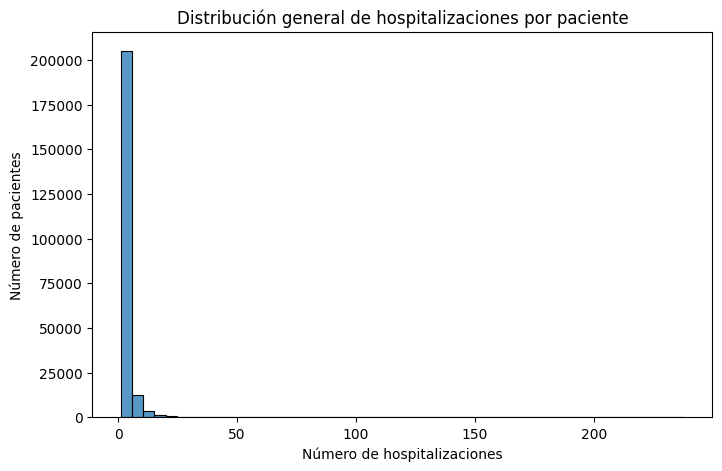

In [11]:
#grafico 1 distribucción general

plt.figure(figsize=(8,5))

sns.histplot(admissions_per_patient, bins=50)

plt.title("Distribución general de hospitalizaciones por paciente")
plt.xlabel("Número de hospitalizaciones")
plt.ylabel("Número de pacientes")

plt.show()

La mayoría de los pacientes presentan una única hospitalización, mientras que un número reducido de pacientes 
presenta múltiples ingresos hospitalarios.


Gráfico 2 de dist de hosp por paciente 

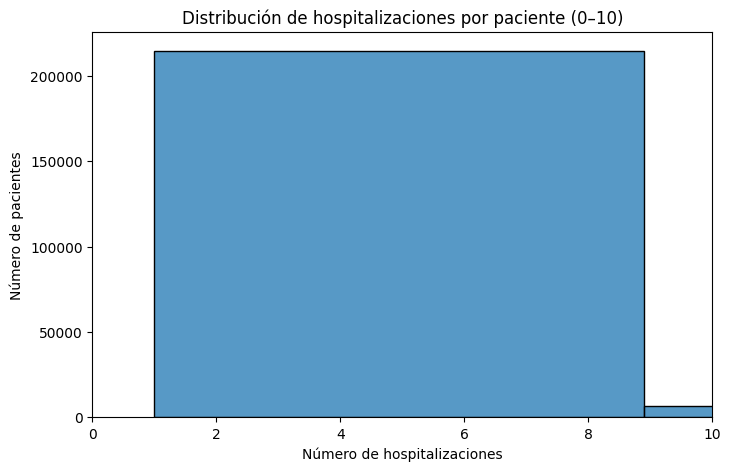

In [12]:
#grafico 2 para verlo más en detalle
plt.figure(figsize=(8,5))

sns.histplot(admissions_per_patient, bins=30)

plt.xlim(0,10)

plt.title("Distribución de hospitalizaciones por paciente (0–10)")
plt.xlabel("Número de hospitalizaciones")
plt.ylabel("Número de pacientes")

plt.show()

Gráfico 3 para ver outliers

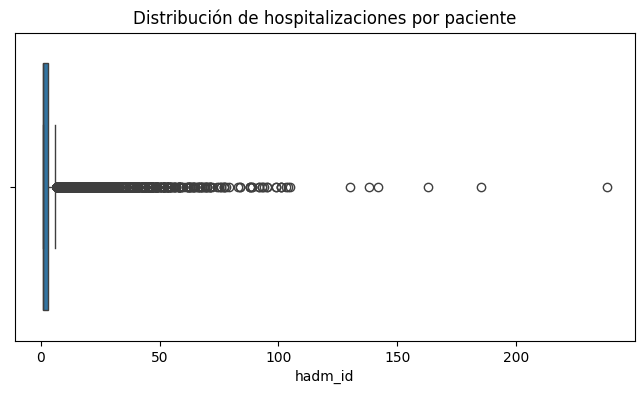

In [13]:
#Gráfico 3 — ver outliers
plt.figure(figsize=(8,4))

sns.boxplot(x=admissions_per_patient)

plt.title("Distribución de hospitalizaciones por paciente")

plt.show()

# 4 Análisis de datos de los pacientes


EDAD 

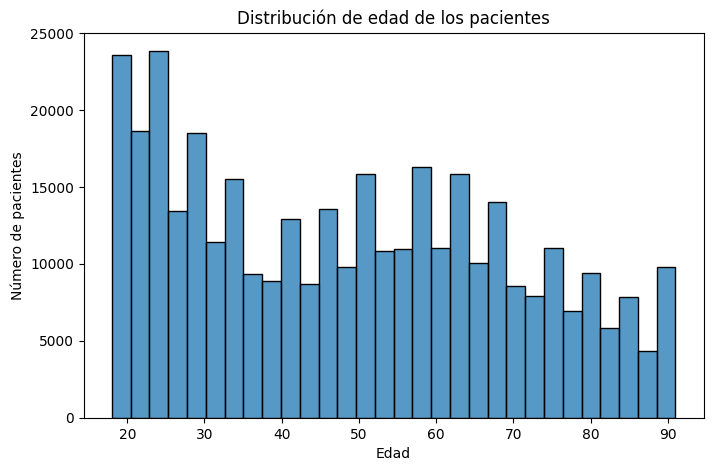

In [14]:
plt.figure(figsize=(8,5))

sns.histplot(patients["anchor_age"], bins=30)

plt.title("Distribución de edad de los pacientes")
plt.xlabel("Edad")
plt.ylabel("Número de pacientes")

plt.show()

Genero


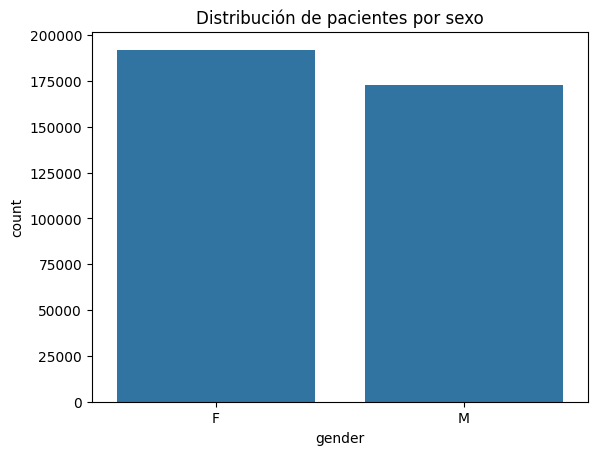

In [15]:
#Distribución de género
patients["gender"].value_counts()

sns.countplot(data=patients, x="gender")

plt.title("Distribución de pacientes por sexo")
plt.show()

# 5 ANÁLISIS DE LAS HOSPITALIZACIONES

In [17]:
#Duración de las hospitalizaciones
import pandas as pd 
admissions["admittime"] = pd.to_datetime(admissions["admittime"])
admissions["dischtime"] = pd.to_datetime(admissions["dischtime"])

#Calculamos la duración de cada hospitalización en días
admissions["length_of_stay"] = (
    admissions["dischtime"] - admissions["admittime"]
).dt.days

print("Duración media de las hospitalizaciones (días):", admissions["length_of_stay"].mean())

Duración media de las hospitalizaciones (días): 4.221032621037749


#Gráfico 1 distr de la duración de la hosp por paciente (general)

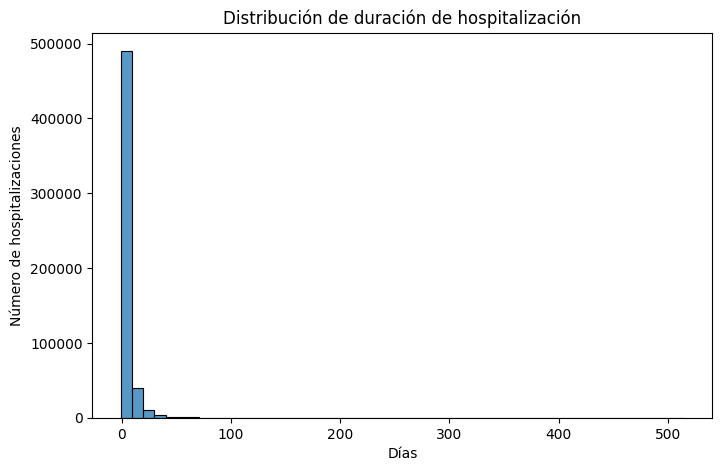

In [18]:
#Gráfico 1 general 
plt.figure(figsize=(8,5))

sns.histplot(admissions["length_of_stay"], bins=50)

plt.title("Distribución de duración de hospitalización")
plt.xlabel("Días")
plt.ylabel("Número de hospitalizaciones")

plt.show()

#Gráfico 2 (más en detalle)

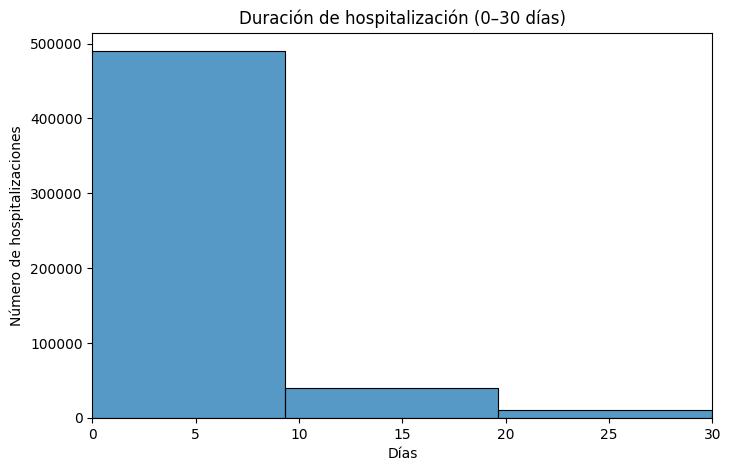

In [19]:
#2 grafico para verlo más en detalle 
plt.figure(figsize=(8,5))

sns.histplot(admissions["length_of_stay"], bins=50)

plt.xlim(0,30)

plt.title("Duración de hospitalización (0–30 días)")
plt.xlabel("Días")
plt.ylabel("Número de hospitalizaciones")

plt.show()

#Gráfico 3 para ver outliers en la distr de la duración por paciente

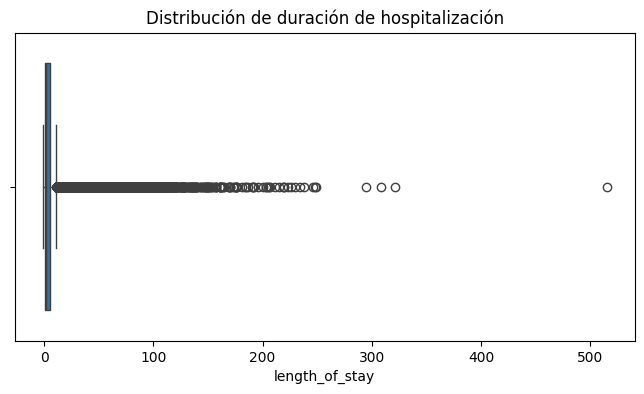

In [20]:
#Gráfico 3 — ver outliers
plt.figure(figsize=(8,4))

sns.boxplot(x=admissions["length_of_stay"])

plt.title("Distribución de duración de hospitalización")

plt.show()

La mayoría de hospitalizaciones duran pocos días.

Tipo de admisión

In [21]:
admissions["admission_type"].value_counts()

admission_type
EW EMER.                       177459
EU OBSERVATION                 119456
OBSERVATION ADMIT               84437
URGENT                          54929
SURGICAL SAME DAY ADMISSION     42898
DIRECT OBSERVATION              24551
DIRECT EMER.                    21973
ELECTIVE                        13130
AMBULATORY OBSERVATION           7195
Name: count, dtype: int64

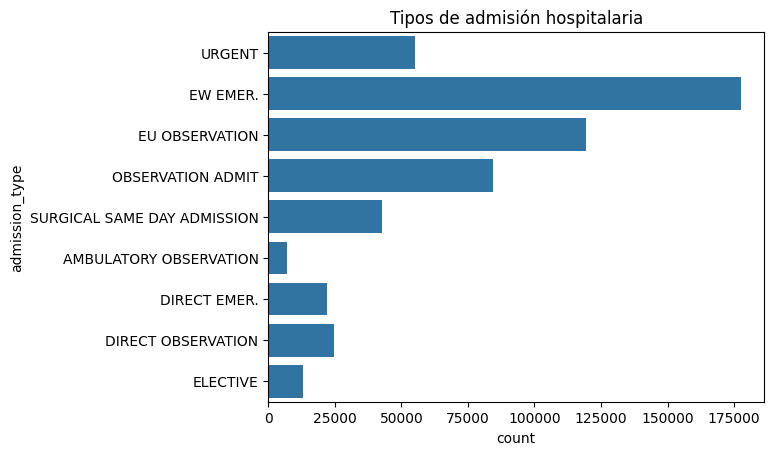

In [22]:
sns.countplot(y="admission_type", data=admissions)
plt.title("Tipos de admisión hospitalaria")
plt.show()

# 6. ANÁLISIS CLINICO


Diagnósticos más frecuentes

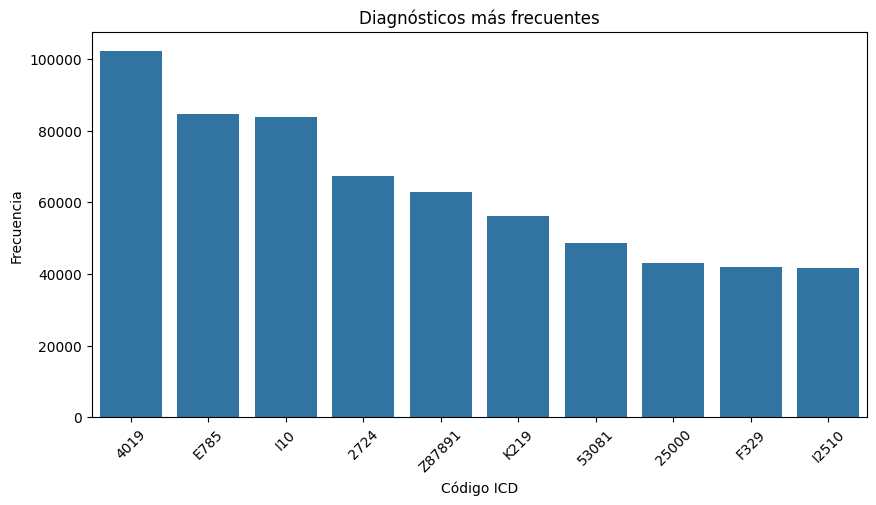

In [23]:
#Grafico para ver los diagnósticos más frecuentes   
top_diagnoses = diagnoses["icd_code"].value_counts().head(10)

plt.figure(figsize=(10,5))

sns.barplot(x=top_diagnoses.index, y=top_diagnoses.values)

plt.title("Diagnósticos más frecuentes")
plt.xlabel("Código ICD")
plt.ylabel("Frecuencia")

plt.xticks(rotation=45)

plt.show()

Número de diagnósticos por hospitalización

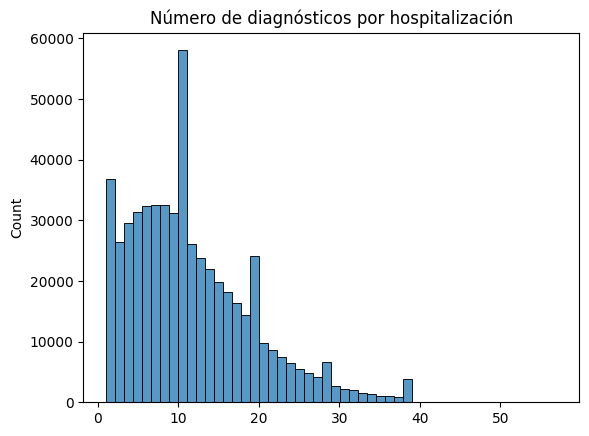

In [24]:
diagnoses_per_admission = diagnoses.groupby("hadm_id").size()

sns.histplot(diagnoses_per_admission, bins=50)
plt.title("Número de diagnósticos por hospitalización")
plt.show()

 Analisis de diagnósticos

In [25]:
procedures["icd_code"].value_counts().head(10)


icd_code
3893       14644
02HV33Z    14353
8938       10519
3897       10347
8856        9549
3E0G76Z     8700
966         8165
3995        7808
0040        7581
9671        7382
Name: count, dtype: int64

In [26]:
prescriptions["drug"].value_counts().head(10)

drug
Insulin                        845166
0.9% Sodium Chloride           728089
Potassium Chloride             674552
Sodium Chloride 0.9%  Flush    673380
Acetaminophen                  586860
Furosemide                     446724
Heparin                        396579
5% Dextrose                    368167
Magnesium Sulfate              367223
Bag                            352882
Name: count, dtype: int64

In [ ]:
missing_values = admissions.isnull().sum().sort_values(ascending=False)
missing_values

deathtime               534238
edregtime               166788
edouttime               166788
discharge_location      149818
marital_status           13619
insurance                 9355
language                   775
admit_provider_id            4
admission_location           1
subject_id                   0
hadm_id                      0
admittime                    0
dischtime                    0
admission_type               0
race                         0
hospital_expire_flag         0
length_of_stay               0
dtype: int64